In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [2]:
df = pd.read_csv("train.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
# Check all values
print(df.isna())

     PassengerId  Survived  Pclass   Name    Sex    Age  SibSp  Parch  Ticket  \
0          False     False   False  False  False  False  False  False   False   
1          False     False   False  False  False  False  False  False   False   
2          False     False   False  False  False  False  False  False   False   
3          False     False   False  False  False  False  False  False   False   
4          False     False   False  False  False  False  False  False   False   
..           ...       ...     ...    ...    ...    ...    ...    ...     ...   
886        False     False   False  False  False  False  False  False   False   
887        False     False   False  False  False  False  False  False   False   
888        False     False   False  False  False   True  False  False   False   
889        False     False   False  False  False  False  False  False   False   
890        False     False   False  False  False  False  False  False   False   

      Fare  Cabin  Embarked

In [4]:
print(df.isna().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [5]:
# checking duplicate rows
df.duplicated()[df.duplicated()==True]

Series([], dtype: bool)

In [6]:
# finding number of rows and columns

print("Shape (rows, columns): ", df.shape,"\n")

print("number of rows: ", df.shape[0])
print("number of columns: ", df.shape[1])

Shape (rows, columns):  (891, 12) 

number of rows:  891
number of columns:  12


In [7]:
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object

In [14]:
df['Age'] = pd.to_numeric(df['Age'])
df['Fare'] = pd.to_numeric(df['Fare'])
df['PassengerId'] = pd.to_numeric(df['PassengerId'])

df.dtypes


PassengerId       int64
Survived          int64
Pclass            int64
Name                str
Sex            category
Age             float64
SibSp             int64
Parch             int64
Ticket              str
Fare            float64
Cabin               str
Embarked       category
dtype: object

In [15]:
# Statistical summary
df.describe(include='all')

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Braund, Mr. Owen Harris",male,NaN,NaN,NaN,347082,NaN,G6,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


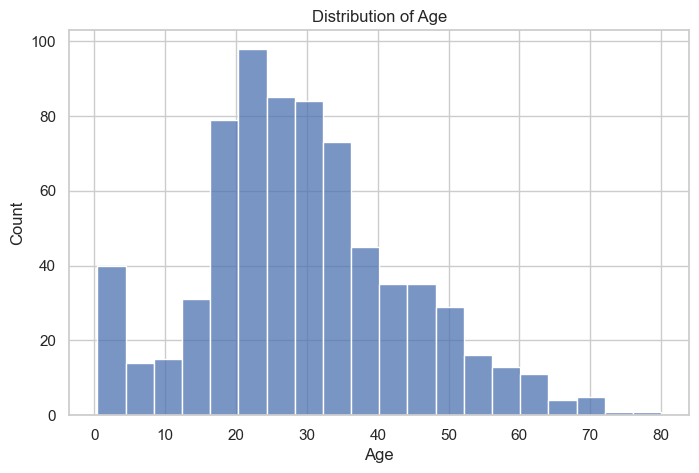

In [17]:
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=20)
plt.title("Distribution of Age")
plt.show()


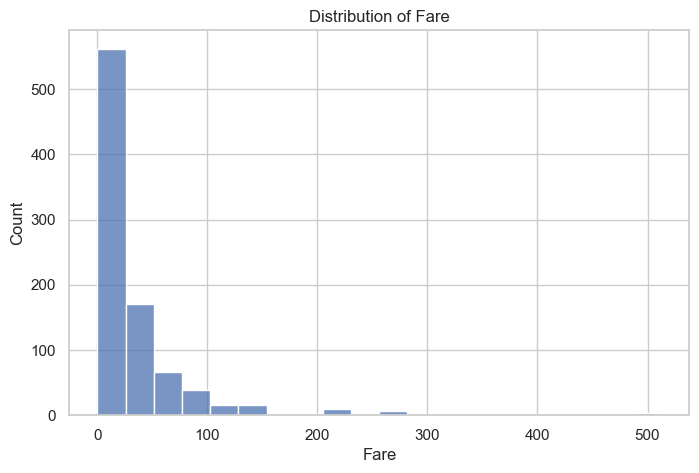

In [18]:
plt.figure(figsize=(8,5))
sns.histplot(df['Fare'], bins=20)
plt.title("Distribution of Fare")
plt.show()

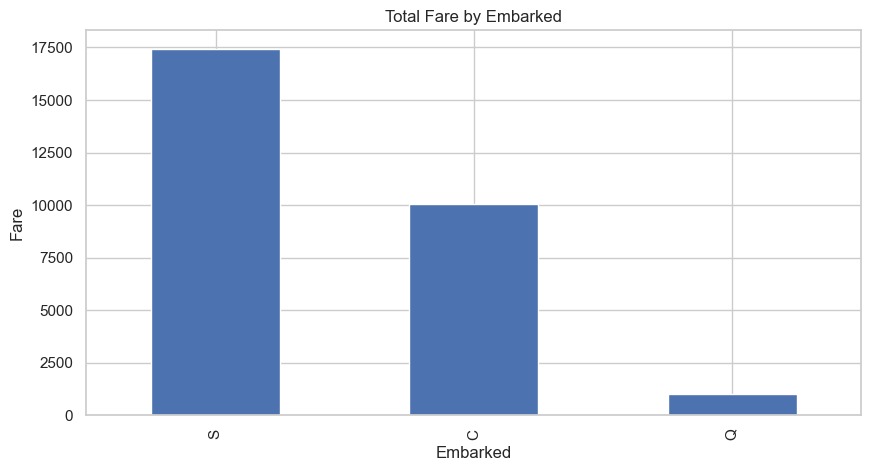

Embarked
S    17439.3988
C    10072.2962
Q     1022.2543
Name: Fare, dtype: float64

In [19]:
country_revenue = df.groupby('Embarked')['Fare'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))
country_revenue.plot(kind='bar')
plt.title("Total Fare by Embarked")
plt.ylabel("Fare")
plt.show()

country_revenue


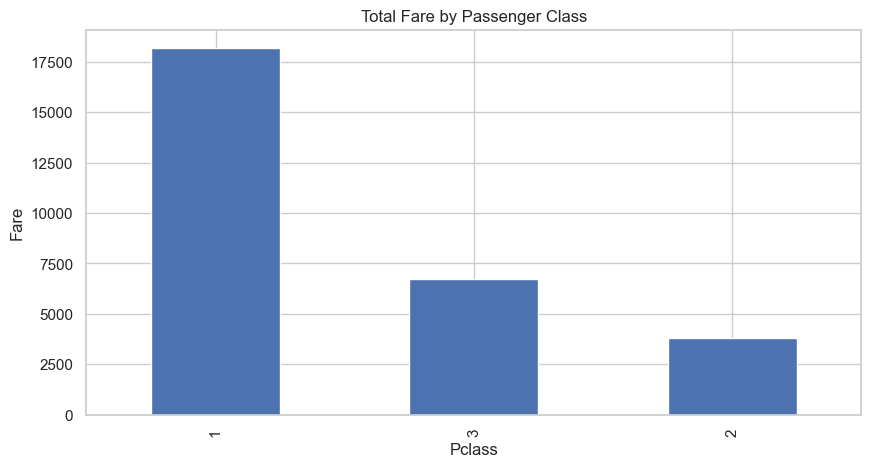

Pclass
1    18177.4125
3     6714.6951
2     3801.8417
Name: Fare, dtype: float64

In [20]:
product_revenue = df.groupby('Pclass')['Fare'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))
product_revenue.plot(kind='bar')
plt.title("Total Fare by Passenger Class")
plt.ylabel("Fare")
plt.show()

product_revenue

In [26]:
salesperson_revenue = df.groupby('Sex')['Fare'].sum().sort_values(ascending=False)

salesperson_revenue.head(10)


Sex
male      14727.2865
female    13966.6628
Name: Fare, dtype: float64

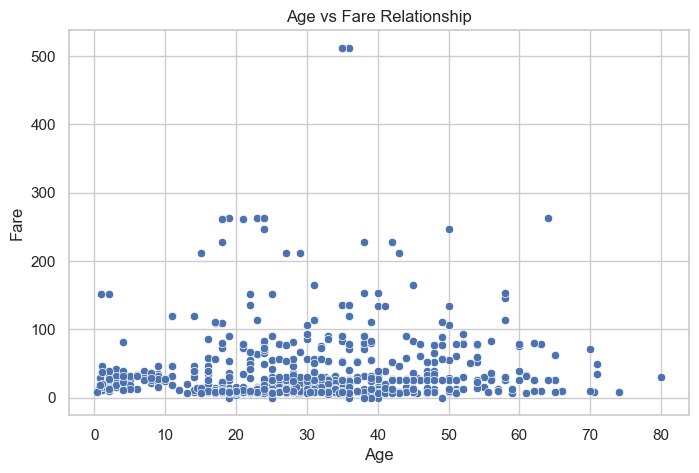

In [27]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Age', y='Fare', data=df)
plt.title("Age vs Fare Relationship")
plt.show()


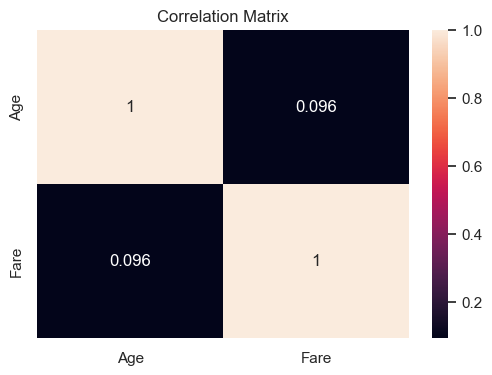

In [28]:
plt.figure(figsize=(6,4))
sns.heatmap(df[['Age', 'Fare']].corr(), annot=True)
plt.title("Correlation Matrix")
plt.show()


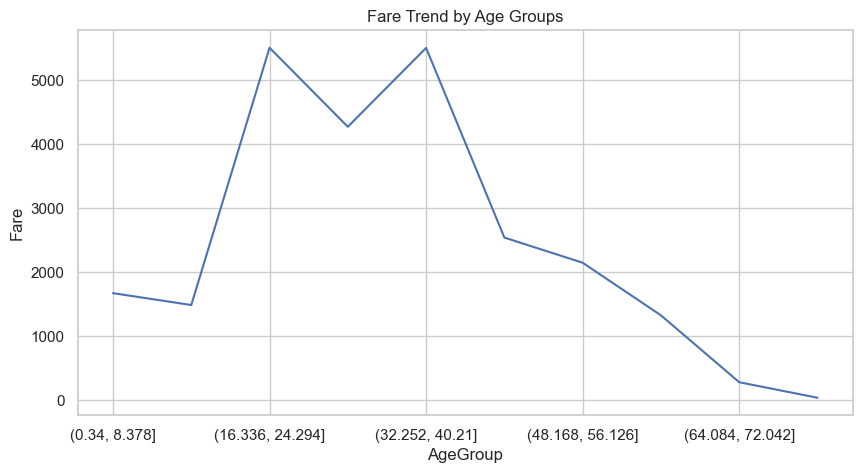

In [29]:
df['AgeGroup'] = pd.cut(df['Age'], bins=10)

monthly_revenue = df.groupby('AgeGroup')['Fare'].sum()

plt.figure(figsize=(10,5))
monthly_revenue.plot()
plt.title("Fare Trend by Age Groups")
plt.ylabel("Fare")
plt.show()